In [323]:
!cp /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf /content/Arial.ttf
import os
if os.path.exists('/content/Arial.ttf'):
    print('Successfully created /content/Arial.ttf from system fonts.')

Successfully created /content/Arial.ttf from system fonts.


# Computer Vision Homework 2
### Sarvenaz Salehi - 810101462

##Part1 - Data generation
1. generating 20 images using pilow library

2. save and label images

In [324]:
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import random
import string
import os

# Clear old images if they exist to avoid confusion
if os.path.exists("imgs"):
    import shutil
    shutil.rmtree("imgs")
os.makedirs("imgs", exist_ok=True)

ground_truth_map = {}

font_paths_to_try = [

    "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
]

img_w, img_h = 200, 100
font_size = 40
font = None

for path in font_paths_to_try:
    if os.path.exists(path):
        try:
            font = ImageFont.truetype(path, font_size)
            print(f"Success: Loaded font from {path}")
            break
        except:
            continue

if font is None:
    font = ImageFont.load_default()

for i in range(20):
    # Generate random text
    text = ''.join(random.choices(string.ascii_lowercase + string.digits, k=4))

    # Use generic naming convention
    filename = f"img{i}.png"
    ground_truth_map[filename] = text

    img = Image.new('RGB', (img_w, img_h), color = "white")
    draw = ImageDraw.Draw(img)

    bbox = draw.textbbox((0, 0), text, font=font)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x, y = (img_w - tw) // 2, (img_h - th) // 2 - (bbox[1] if hasattr(font, 'getmetrics') else 0)

    draw.text((x, y), text, fill="black", font=font)
    img.save(os.path.join("imgs", filename))

print(f"20 images generated with generic names (e.g., '{list(ground_truth_map.keys())[0]}').")

Success: Loaded font from /usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf
20 images generated with generic names (e.g., 'img0.png').


3. add salt and paper noise and compare with the original images

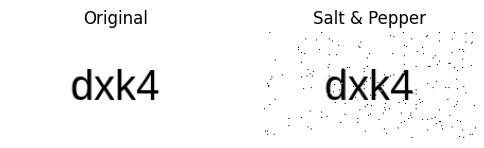

In [325]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from PIL import Image, ImageDraw, ImageFont

input_dir = "imgs"
output_dir = "noisy_imgs"
os.makedirs(output_dir, exist_ok=True)

def add_salt_pepper(img, amount=0.01):
    arr = np.array(img).copy()
    h, w = arr.shape[:2]
    n = int(amount * h * w)

    for _ in range(n):
        x, y = random.randint(0, h-1), random.randint(0, w-1)
        arr[x, y] = 255   # salt

    for _ in range(n):
        x, y = random.randint(0, h-1), random.randint(0, w-1)
        arr[x, y] = 0     # pepper

    return Image.fromarray(arr)

files = [f for f in os.listdir(input_dir) if f.endswith(".png")]

first_original = None
first_noisy = None

for i, file in enumerate(files):
    img = Image.open(os.path.join(input_dir, file)).convert("RGB")
    noisy = add_salt_pepper(img)

    noisy.save(os.path.join(output_dir, file))

    if i == 1:
        first_original = img
        first_noisy = noisy

# show only first comparison
plt.figure(figsize=(6, 3))

plt.subplot(1, 2, 1)
plt.imshow(first_original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(first_noisy)
plt.title("Salt & Pepper")
plt.axis("off")

plt.show()

4. filtering images
what kernel and why

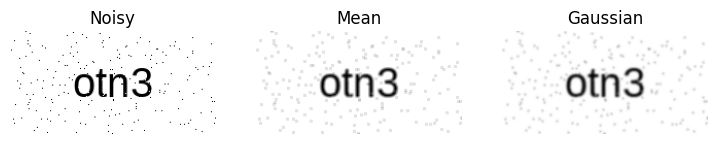

In [326]:
from PIL import Image, ImageFilter
file = random.choice(os.listdir("noisy_imgs"))

img = Image.open(f"noisy_imgs/{file}")

mean_img = img.filter(ImageFilter.BoxBlur(1))
gauss_img = img.filter(ImageFilter.GaussianBlur(1))

plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Noisy")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mean_img)
plt.title("Mean")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(gauss_img)
plt.title("Gaussian")
plt.axis("off")

plt.show()

## Part2 - Data Preprocessing

1.why do filters that cause blur, reduce noise?

Blur filters reduce noise because they smooth neighboring pixel values together.

Random noise, such as salt-and-pepper noise, appears as sudden sharp changes between pixels.

 Mean and Gaussian filters replace each pixel with an average of nearby pixels, reducing these sudden variations.

The tradeoff is that important image details, such as edges and text boundaries, are also smoothed. This is why the image becomes blurrier while the noise level decreases.

A mean filter gives equal importance to all neighboring pixels, while a Gaussian filter gives more importance to closer pixels, usually preserving image structure slightly better.


1.2 . noise reduction using median kernel:

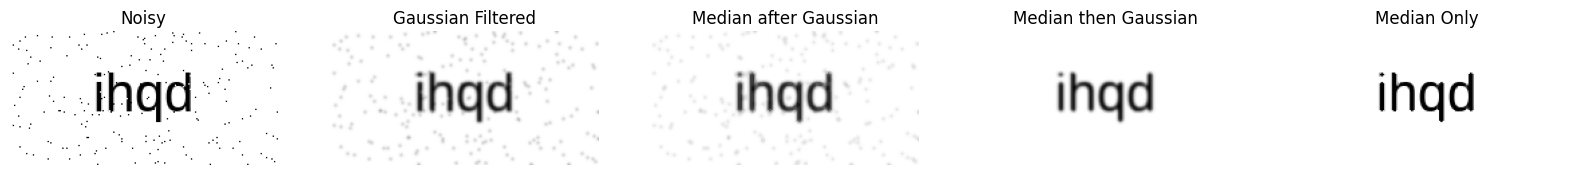

In [327]:
from PIL import Image, ImageFilter
import os, random
import matplotlib.pyplot as plt

input_dir_noisy = "noisy_imgs"
output_dir_median_only = "median_filtered_imgs"
output_dir_median_then_gaussian = "median_then_gaussian_filtered_imgs"

os.makedirs(output_dir_median_only, exist_ok=True)
os.makedirs(output_dir_median_then_gaussian, exist_ok=True)

files = [f for f in os.listdir(input_dir_noisy) if f.endswith(".png")]

first_noisy = None
first_gaussian_for_display = None
first_median_after_gaussian_for_display = None
first_median_only_for_display = None
first_median_then_gaussian_for_display = None

for i, file_name in enumerate(files):
    # Load the noisy image
    img_noisy = Image.open(os.path.join(input_dir_noisy, file_name)).convert("RGB")

    # Apply ONLY Median filter and save it (as requested previously)
    img_median_only = img_noisy.filter(ImageFilter.MedianFilter(3))
    img_median_only.save(os.path.join(output_dir_median_only, file_name))

    # Apply Median filter then Gaussian filter and save it (as requested now)
    img_median_first = img_noisy.filter(ImageFilter.MedianFilter(3))
    img_median_then_gaussian = img_median_first.filter(ImageFilter.GaussianBlur(1))
    img_median_then_gaussian.save(os.path.join(output_dir_median_then_gaussian, file_name))

    # For comparison, process the *first* image with Gaussian and Gaussian+Median
    if i == 0:
        first_noisy = img_noisy
        first_median_only_for_display = img_median_only # Store for display

        first_gaussian_for_display = img_noisy.filter(ImageFilter.GaussianBlur(1))

        first_median_after_gaussian_for_display = first_gaussian_for_display.filter(ImageFilter.MedianFilter(3))

        first_median_then_gaussian_for_display = img_median_then_gaussian

# Display the comparison for the first image
plt.figure(figsize=(20, 4)) # Increased figsize for 5 images

images_to_show = [
    (first_noisy, "Noisy"),
    (first_gaussian_for_display, "Gaussian Filtered"),
    (first_median_after_gaussian_for_display, "Median after Gaussian"),
    (first_median_then_gaussian_for_display, "Median then Gaussian"),
    (first_median_only_for_display, "Median Only")
]

for i, (im, title) in enumerate(images_to_show):
    plt.subplot(1, 5, i + 1) # Changed to 1, 5 for 5 images
    plt.imshow(im)
    plt.title(title)
    plt.axis("off")

plt.show()

As shown in the result, median+gaussian denoises the images more effectively. therefore we continue with that result.

In [328]:
import os
import random
from PIL import Image, ImageFilter
import numpy as np
import cv2

# --- Define directories ---
input_dir_noisy = "noisy_imgs"
output_dir_final_processed = "all_final_processed_imgs"

os.makedirs(output_dir_final_processed, exist_ok=True)

# Sharpening kernel
sharpen_kernel = ImageFilter.Kernel(
    (3, 3),
    [0, -1, 0,
     -1, 5, -1,
     0, -1, 0]
)

all_noisy_files = [f for f in os.listdir(input_dir_noisy) if f.endswith(".png")]

print(f"Applying full pipeline to {len(all_noisy_files)} images...")
for file_name in all_noisy_files:
    # file_name is already the ground truth, e.g., 'TN2A.png'
    img_noisy = Image.open(os.path.join(input_dir_noisy, file_name)).convert("RGB")

    # 1. Median then Gaussian
    img_filtered = img_noisy.filter(ImageFilter.MedianFilter(3)).filter(ImageFilter.GaussianBlur(1))

    # 2. Sharpening
    img_sharpened = img_filtered.filter(sharpen_kernel)

    # 3. Binarization and Connected Components
    img_gray = np.array(img_sharpened.convert("L"))
    _, binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)
    result = binary.copy()
    for label_idx in range(1, num_labels):
        if stats[label_idx, cv2.CC_STAT_AREA] < 20:
            result[labels == label_idx] = 255

    # Save keeping the original filename as the ground truth label
    Image.fromarray(result).save(os.path.join(output_dir_final_processed, file_name))

print(f"All processed images saved in '{output_dir_final_processed}' with labels as filenames.")

Applying full pipeline to 20 images...
All processed images saved in 'all_final_processed_imgs' with labels as filenames.


2. de-blurring and sharpening
* **Deblurring and Sharpening**

  * **Deblurring:**
    Deblurring tries to recover the original image by reducing the effect of blur. Advanced approaches such as deconvolution estimate how the blur was created and attempt to reverse it mathematically. Although these methods can restore details, they are usually sensitive to noise and require accurate knowledge of the blur pattern.

  * **Sharpening:**
    Sharpening improves the visual clarity of an image by increasing the contrast around edges. Instead of reconstructing lost information, it enhances existing details so objects and text appear more defined.

* **Chosen Method: Sharpening**

  In this project, sharpening was selected because it is easier to implement, faster to process, and works effectively for improving blurred text images. Since our work focuses on spatial filtering and kernels, sharpening is also more consistent with the overall goal of the experiment.

  The following sharpening kernel was used:

  [
  K =
  \begin{bmatrix}
  0 & -1 & 0 \\
  -1 & 5 & -1 \\
  0 & -1 & 0
  \end{bmatrix}
  ]

  This kernel strengthens the center pixel while subtracting part of the neighboring pixels. As a result, intensity transitions become stronger, edges become clearer, and the image appears sharper.


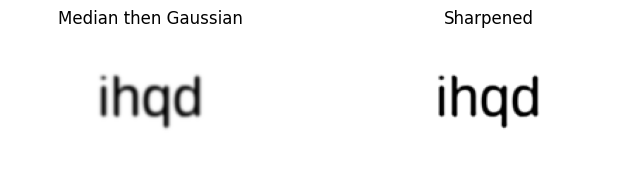

In [329]:
from PIL import Image, ImageFilter
import os
import matplotlib.pyplot as plt
import numpy as np

input_dir_filtered = "median_then_gaussian_filtered_imgs"
output_dir_sharpened = "sharpened_imgs"
os.makedirs(output_dir_sharpened, exist_ok=True)

# Sharpening kernel
sharpen_kernel = ImageFilter.Kernel(
    (3, 3), # size (width, height)
    [0, -1, 0,
     -1, 5, -1,
     0, -1, 0]
)

files = [f for f in os.listdir(input_dir_filtered) if f.endswith(".png")]

first_filtered_img = None
first_sharpened_img = None

for i, file_name in enumerate(files):
    img = Image.open(os.path.join(input_dir_filtered, file_name)).convert("RGB")
    sharpened_img = img.filter(sharpen_kernel)
    sharpened_img.save(os.path.join(output_dir_sharpened, file_name))

    if i == 0:
        first_filtered_img = img
        first_sharpened_img = sharpened_img

# Display the comparison for the first image
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(first_filtered_img)
plt.title("Median then Gaussian")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(first_sharpened_img)
plt.title("Sharpened")
plt.axis("off")

plt.show()

3. remove noise using binarization


In this method, the image is first converted into a binary image, meaning each pixel becomes either black or white. Then, connected regions (Connected Components) are detected. The main idea is that noise usually appears as very small isolated regions, so components smaller than a chosen threshold can be removed.

The threshold in this method represents the minimum allowed size of a connected region. If the number of pixels in a component is smaller than this threshold, the region is considered noise and removed.

The threshold is not a fixed value. It depends on factors such as image resolution, amount of noise, and the size of the main objects in the image. If the threshold is too small, some noise may remain. If it is too large, important parts of the characters or objects may also be removed.

Processing 20 images...
All binarized images saved in 'binarized_imgs'.


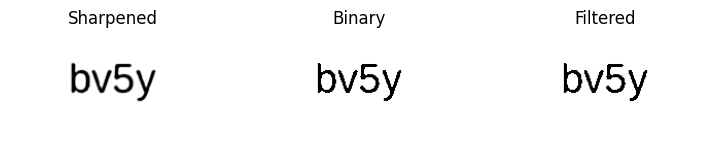

In [330]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

input_dir = "sharpened_imgs"
output_dir = "binarized_imgs"
os.makedirs(output_dir, exist_ok=True)

threshold = 20
files = [f for f in os.listdir(input_dir) if f.endswith(".png")]

print(f"Processing {len(files)} images...")

for file_name in files:
    img = cv2.imread(os.path.join(input_dir, file_name), 0)
    if img is None: continue

    # binary image
    _, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary)

    result = binary.copy()
    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < threshold:
            result[labels == i] = 0

    cv2.imwrite(os.path.join(output_dir, file_name), result)

print(f"All binarized images saved in '{output_dir}'.")

# Visualize the last processed image
plt.figure(figsize=(9,3))
plt.subplot(1,3,1); plt.imshow(img, cmap='gray'); plt.title('Sharpened'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(binary, cmap='gray'); plt.title('Binary'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(result, cmap='gray'); plt.title('Filtered'); plt.axis('off')
plt.show()

Inverting 20 images to black background...
Done! Folder 'binarized_imgs' now contains black background images.


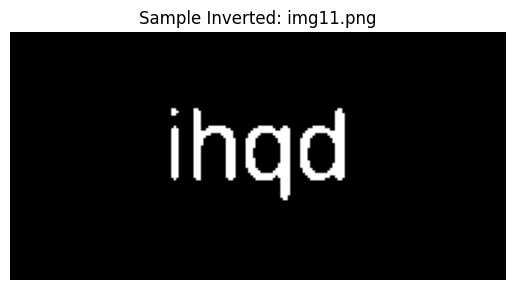

In [331]:
import cv2
import os
import matplotlib.pyplot as plt

bin_dir = "binarized_imgs"
files = [f for f in os.listdir(bin_dir) if f.endswith(".png")]

print(f"Inverting {len(files)} images to black background...")

for file_name in files:
    path = os.path.join(bin_dir, file_name)
    img = cv2.imread(path, 0)
    if img is None: continue

    # Invert the image: white becomes black, black becomes white
    inverted = cv2.bitwise_not(img)

    # Overwrite the original file with the inverted version
    cv2.imwrite(path, inverted)

print("Done! Folder 'binarized_imgs' now contains black background images.")

# Show a sample result
if len(files) > 0:
    sample = cv2.imread(os.path.join(bin_dir, files[0]), 0)
    plt.imshow(sample, cmap='gray')
    plt.title(f"Sample Inverted: {files[0]}")
    plt.axis('off')
    plt.show()

## Part 3 - Segmentation
1.
In this section, the filtered binary images are segmented in order to extract each character separately. Since the CAPTCHA images contain four characters, the goal is to identify connected character regions and save each one as an independent binary image.

The segmentation process is based on Connected Component Analysis. After converting the image to binary form and removing small noisy regions, connected white pixel regions are detected. Each connected region is assumed to represent a character.

The main steps are:

1.Convert the filtered image into a binary image.

2.Detect connected components.

3.Remove very small components that correspond to remaining noise.

4.Extract bounding boxes around valid components.

5.Crop each character separately.

6.Resize each segmented character to 64×64 pixels so that all outputs have the same dimensions as the reference images in the Mapset dataset.


The number of extracted components is also reported for each image. In ideal conditions, four valid character regions should be detected for every CAPTCHA image.

In [332]:
import cv2, os, re
import matplotlib.pyplot as plt
import numpy as np

INPUT_DIR = "binarized_imgs"
OUTPUT_DIR = "segmented_chars"
TARGET_SIZE = (64, 64)

if os.path.exists(OUTPUT_DIR):
    import shutil
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', s)]

files = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith(".png")], key=natural_sort_key)

print(f"Segmenting characters from {len(files)} images...")

for file in files:
    # Load the binarized image (White text on Black background)
    img_bw = cv2.imread(os.path.join(INPUT_DIR, file), 0)
    if img_bw is None: continue

    # Use connected components to find white characters
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(img_bw, 8)

    chars = []
    for label in range(1, num_labels):
        x, y, w, h, area = stats[label]

        # Filter out very small noise components
        if area < 15: continue

        # Crop the character
        char_crop = img_bw[y:y+h, x:x+w]

        # Resize to standard size (64x64) for recognition
        char_resized = cv2.resize(char_crop, TARGET_SIZE, interpolation=cv2.INTER_NEAREST)
        chars.append((x, char_resized))

    # Sort characters from left to right based on x-coordinate
    chars.sort(key=lambda item: item[0])

    # Create a subfolder for each CAPTCHA image
    folder_name = os.path.splitext(file)[0]
    folder_path = os.path.join(OUTPUT_DIR, folder_name)
    os.makedirs(folder_path, exist_ok=True)

    for i, (_, char_img) in enumerate(chars):
        cv2.imwrite(os.path.join(folder_path, f"char_{i+1}.png"), char_img)

print(f"Characters segmented and saved in '{OUTPUT_DIR}'")

Segmenting characters from 20 images...
Characters segmented and saved in 'segmented_chars'


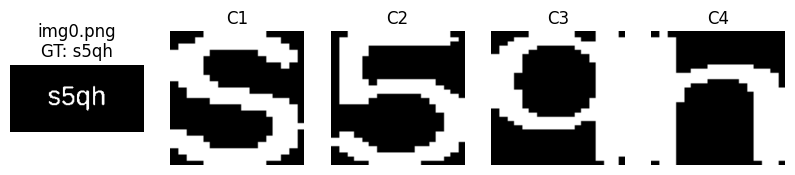

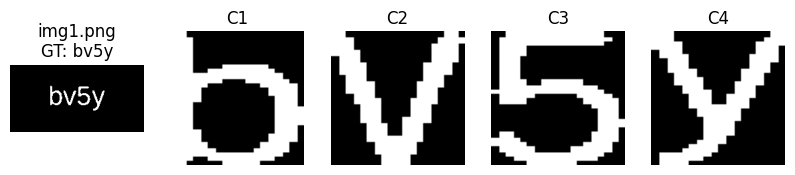

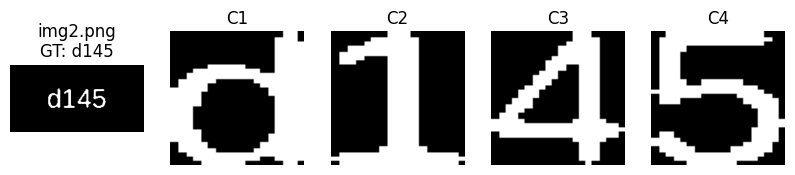

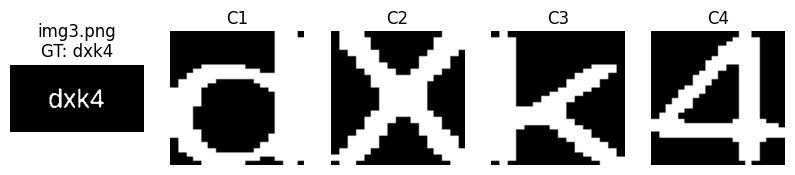

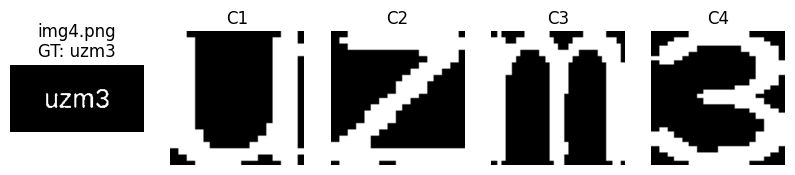

In [333]:
import cv2, os
import matplotlib.pyplot as plt

# Visualization for the first 5 processed images
processed_files = sorted([f for f in os.listdir(INPUT_DIR) if f.endswith(".png")], key=natural_sort_key)

for idx in range(min(5, len(processed_files))):
    file_name = processed_files[idx]
    img = cv2.imread(os.path.join(INPUT_DIR, file_name), 0)

    # Load segmented characters from the subfolder
    folder_name = os.path.splitext(file_name)[0]
    char_folder_path = os.path.join(OUTPUT_DIR, folder_name)

    char_files = sorted(os.listdir(char_folder_path), key=natural_sort_key)
    chars = [cv2.imread(os.path.join(char_folder_path, cf), 0) for cf in char_files]

    true_text = ground_truth_map.get(file_name, "????")

    plt.figure(figsize=(10, 2))
    plt.subplot(1, len(chars)+1, 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"{file_name}\nGT: {true_text}")
    plt.axis("off")

    for i, char in enumerate(chars):
        plt.subplot(1, len(chars)+1, i+2)
        plt.imshow(char, cmap="gray")
        plt.title(f"C{i+1}")
        plt.axis("off")

    plt.show()

## Part 4 - Character Recegnition
1. similarity analysis between mapset and generated images
save each segmented image with a metric in a csv file

In [334]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


Loaded templates: 35

File: char_1.png
Prediction: s
Score: 0.6579


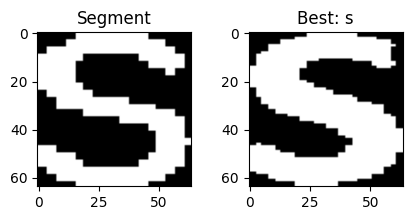


File: char_2.png
Prediction: 5
Score: 0.5075


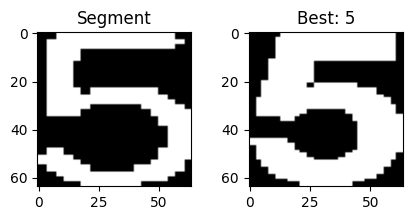


File: char_3.png
Prediction: q
Score: 0.682


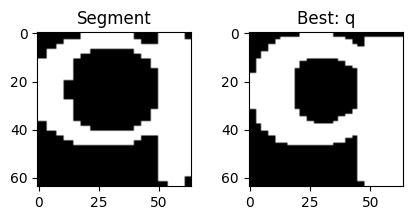


File: char_4.png
Prediction: h
Score: 0.5984


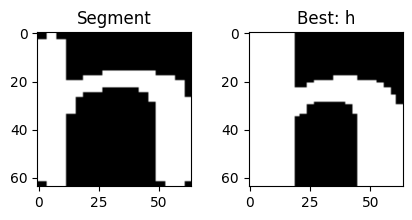


Final prediction: s5qh


In [335]:
import os, cv2, re
import numpy as np
import matplotlib.pyplot as plt

MAPSET_PATH = "/content/drive/MyDrive/Mapset"
SEGMENTED_PATH = "segmented_chars"
IMAGE_FOLDER = "img0"
SIZE = (64, 64)

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split("([0-9]+)", s)]

# Load Mapset
mapset_images = []

for root, dirs, files in os.walk(MAPSET_PATH):
    for f in sorted(files, key=natural_sort_key):

        if not f.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        path = os.path.join(root, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None or np.std(img) < 1:
            continue

        img = cv2.resize(img, SIZE, interpolation=cv2.INTER_NEAREST)
        white_pixels = np.sum(img > 10)

        if white_pixels < 40:
            print("Skipping nearly blank:", f)
            continue
        label = os.path.splitext(f)[0].split("_")[0]

        mapset_images.append({
            "label": label,
            "name": f,
            "image": img
        })

print("Loaded templates:", len(mapset_images))

# Recognize one image folder
folder_path = os.path.join(SEGMENTED_PATH, IMAGE_FOLDER)
char_files = sorted(os.listdir(folder_path), key=natural_sort_key)

predicted_text = ""

for char_file in char_files:

    char_path = os.path.join(folder_path, char_file)
    char = cv2.imread(char_path, cv2.IMREAD_GRAYSCALE)
    char = cv2.resize(char, SIZE, interpolation=cv2.INTER_NEAREST)

    best_label = None
    best_score = -1
    best_ref = None

    for ref in mapset_images:
        ref_img = ref["image"]

        score = cv2.matchTemplate(
            char,
            ref_img,
            cv2.TM_CCOEFF_NORMED
        )[0][0]

        if score > best_score:
            best_score = score
            best_label = ref["label"]
            best_ref = ref_img

    predicted_text += best_label

    print("\nFile:", char_file)
    print("Prediction:", best_label)
    print("Score:", round(best_score, 4))

    plt.figure(figsize=(5, 2))

    plt.subplot(1, 2, 1)
    plt.imshow(char, cmap="gray", vmin=0, vmax=255)
    plt.title("Segment")

    plt.subplot(1, 2, 2)
    plt.imshow(best_ref, cmap="gray", vmin=0, vmax=255)
    plt.title(f"Best: {best_label}")

    plt.show()

print("\nFinal prediction:", predicted_text)

2. repeat 1 for all 20 images and evaluate accuration of the algorithm

In [336]:
import os, cv2, re
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim

MAPSET_PATH = "/content/drive/MyDrive/Mapset"
SEGMENTED_PATH = "segmented_chars"
CSV_PATH = "recognition_results.csv"
SIZE = (64, 64)

def natural_sort_key(s):
    return [int(t) if t.isdigit() else t.lower()
            for t in re.split("([0-9]+)", s)]

# ---------- Load Mapset ----------
mapset_images = []

for root, dirs, files in os.walk(MAPSET_PATH):

    for f in sorted(files, key=natural_sort_key):

        if not f.lower().endswith((".png", ".jpg", ".jpeg")):
            continue

        path = os.path.join(root, f)

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        if np.std(img) < 1:
            continue

        img = cv2.resize(
            img,
            SIZE,
            interpolation=cv2.INTER_NEAREST
        )
        # skip blank / nearly blank templates
        if np.std(img) < 1:
            continue

        white_pixels = np.sum(img > 10)

        if white_pixels < 40:
            print("Skipping nearly blank:", f)
            continue

        label = os.path.splitext(f)[0].split("_")[0].lower()

        mapset_images.append({
            "label": label,
            "name": f,
            "image": img
        })

print("Loaded templates:", len(mapset_images))

# ---------- Recognition ----------
orb = cv2.ORB_create(nfeatures=500)

all_results = []

methods = ["TM", "SSIM", "Corr", "Hist", "MSE", "ORB", "Hu"]

for img_id in sorted(os.listdir(SEGMENTED_PATH),
                     key=natural_sort_key):

    folder_path = os.path.join(SEGMENTED_PATH, img_id)

    if not os.path.isdir(folder_path):
        continue

    # example: img0.png -> "w2h8"
    ground_truth_text = ground_truth_map.get(
        img_id + ".png",
        "????"
    ).lower()

    char_files = sorted(
        os.listdir(folder_path),
        key=natural_sort_key
    )

    for char_idx, char_file in enumerate(char_files):

        char_path = os.path.join(folder_path, char_file)

        char_img = cv2.imread(
            char_path,
            cv2.IMREAD_GRAYSCALE
        )

        if char_img is None:
            continue

        char_img = cv2.resize(
            char_img,
            SIZE,
            interpolation=cv2.INTER_NEAREST
        )

        char_flat = char_img.flatten()

        char_hist = cv2.calcHist(
            [char_img],
            [0],
            None,
            [256],
            [0, 256]
        )

        cv2.normalize(char_hist, char_hist)

        kp1, des1 = orb.detectAndCompute(char_img, None)

        best = {
            "TM": (-1, None),
            "SSIM": (-1, None),
            "Corr": (-1, None),
            "Hist": (-1, None),
            "MSE": (float("inf"), None),
            "ORB": (-1, None),
            "Hu": (float("inf"), None)
        }

        for ref in mapset_images:

            ref_img = ref["image"]
            ref_label = ref["label"]

            ref_flat = ref_img.flatten()

            # ---------- TM ----------
            tm = cv2.matchTemplate(
                char_img,
                ref_img,
                cv2.TM_CCOEFF_NORMED
            )[0][0]

            if tm > best["TM"][0]:
                best["TM"] = (tm, ref_label)

            # ---------- SSIM ----------
            ssim_score = ssim(char_img, ref_img)

            if ssim_score > best["SSIM"][0]:
                best["SSIM"] = (ssim_score, ref_label)

            # ---------- Correlation ----------
            if np.std(char_flat) == 0 or np.std(ref_flat) == 0:
                corr = 0
            else:
                corr = np.corrcoef(
                    char_flat,
                    ref_flat
                )[0, 1]

                if np.isnan(corr):
                    corr = 0

            if corr > best["Corr"][0]:
                best["Corr"] = (corr, ref_label)

            # ---------- Histogram ----------
            ref_hist = cv2.calcHist(
                [ref_img],
                [0],
                None,
                [256],
                [0, 256]
            )

            cv2.normalize(ref_hist, ref_hist)

            hist = cv2.compareHist(
                char_hist,
                ref_hist,
                cv2.HISTCMP_CORREL
            )

            if hist > best["Hist"][0]:
                best["Hist"] = (hist, ref_label)

            # ---------- MSE ----------
            mse = np.mean(
                (
                    char_img.astype(float)
                    - ref_img.astype(float)
                ) ** 2
            )

            if mse < best["MSE"][0]:
                best["MSE"] = (mse, ref_label)

            # ---------- ORB ----------
            kp2, des2 = orb.detectAndCompute(ref_img, None)

            orb_matches = 0

            if des1 is not None and des2 is not None:

                bf = cv2.BFMatcher(
                    cv2.NORM_HAMMING,
                    crossCheck=True
                )

                matches = bf.match(des1, des2)

                good_matches = [
                    m for m in matches
                    if m.distance < 75
                ]

                orb_matches = len(good_matches)

            if orb_matches > best["ORB"][0]:
                best["ORB"] = (orb_matches, ref_label)

            # ---------- Hu ----------
            hu = cv2.matchShapes(
                char_img,
                ref_img,
                cv2.CONTOURS_MATCH_I1,
                0
            )

            if hu < best["Hu"][0]:
                best["Hu"] = (hu, ref_label)

        ground_truth_char = (
            ground_truth_text[char_idx]
            if char_idx < len(ground_truth_text)
            else "?"
        )

        all_results.append({

            "Image": img_id,
            "Char_Index": char_idx + 1,
            "Ground_Truth": ground_truth_char,

            "TM_Prediction": best["TM"][1],
            "TM_Score": round(best["TM"][0], 4),

            "SSIM_Prediction": best["SSIM"][1],
            "SSIM_Score": round(best["SSIM"][0], 4),

            "Corr_Prediction": best["Corr"][1],
            "Corr_Score": round(best["Corr"][0], 4),

            "Hist_Prediction": best["Hist"][1],
            "Hist_Score": round(best["Hist"][0], 4),

            "MSE_Prediction": best["MSE"][1],
            "MSE_Score": round(best["MSE"][0], 2),

            "ORB_Prediction": best["ORB"][1],
            "ORB_Score": best["ORB"][0],

            "Hu_Prediction": best["Hu"][1],
            "Hu_Score": round(best["Hu"][0], 4)
        })

# ---------- Save ----------
df = pd.DataFrame(all_results)

df.to_csv(CSV_PATH, index=False)

print(f"\nFinal results saved to {CSV_PATH}")

print("\n--- Full Recognition Results ---")
print(df.to_string(index=False))

# ---------- Accuracy ----------
print("\n--- Final Accuracy Report ---")

accuracies = {}

for method in methods:

    pred_col = f"{method}_Prediction"

    acc = (
        df["Ground_Truth"].astype(str).str.lower()
        ==
        df[pred_col].astype(str).str.lower()
    ).mean() * 100

    accuracies[method] = acc

    print(
        f"Method: {method:<12} | "
        f"Accuracy (per Char): {acc:.2f}%"
    )

best_method = max(
    accuracies,
    key=accuracies.get
)

print(
    f"\nBest Performing Method (per Char): "
    f"{best_method} with "
    f"{accuracies[best_method]:.2f}% accuracy."
)

Loaded templates: 35

Final results saved to recognition_results.csv

--- Full Recognition Results ---
Image  Char_Index Ground_Truth TM_Prediction  TM_Score SSIM_Prediction  SSIM_Score Corr_Prediction  Corr_Score Hist_Prediction  Hist_Score MSE_Prediction  MSE_Score ORB_Prediction  ORB_Score Hu_Prediction  Hu_Score
 img0           1            s             s    0.6579               s      0.4104               s      0.6579               y      0.9992              s   11827.06              0          0             7    0.0047
 img0           2            5             5    0.5075               h      0.3325               5      0.5075               7      0.9998              5   17494.52              0          0             7    0.0129
 img0           3            q             q    0.6820               q      0.5226               q      0.6820               y      0.9999              q   11207.92              0          0             7    0.0072
 img0           4            h       